In [2]:
pip install fastapi uvicorn yfinance pandas numpy scikit-learn

Enter Stock Symbol (e.g., AAPL or RELIANCE.NS): MSFT
Mean Squared Error: 4.275618734923076
R2 Score: 0.9973264631083409
Next Day Closing Price: 412.69


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


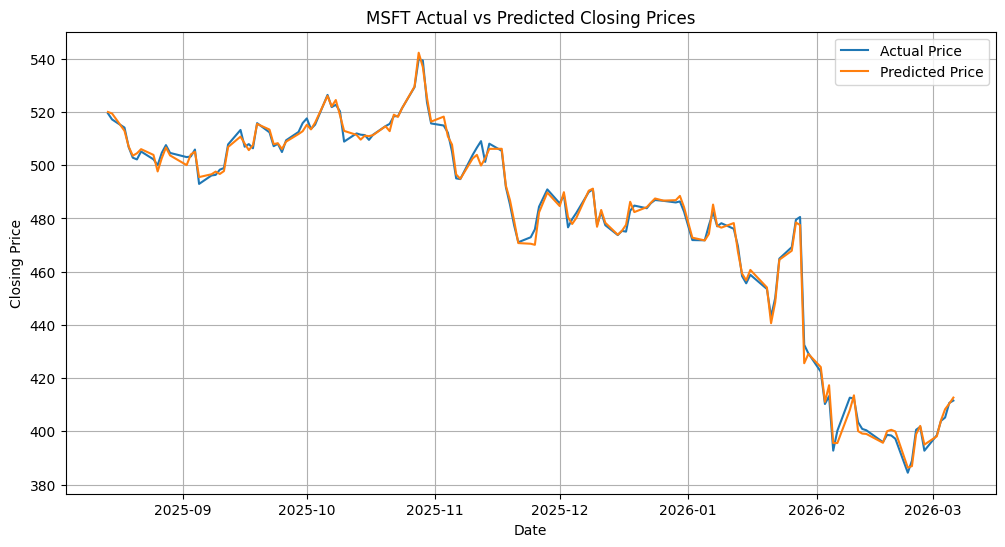

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 1️⃣ INPUT STOCK SYMBOL
# --------------------------------------------------

symbol = input("Enter Stock Symbol (e.g., AAPL or RELIANCE.NS): ").upper().strip()

# --------------------------------------------------
# 2️⃣ FETCH STOCK DATA
# --------------------------------------------------

def fetch_stock_data(symbol, period="3y"):
    stock = yf.Ticker(symbol)
    df = stock.history(period=period)
    df.dropna(inplace=True)
    return df

df = fetch_stock_data(symbol)

# --------------------------------------------------
# 3️⃣ FEATURE ENGINEERING
# --------------------------------------------------

df["Return"] = df["Close"].pct_change()
df["MA10"] = df["Close"].rolling(10).mean()
df["MA50"] = df["Close"].rolling(50).mean()
df["Volatility"] = df["Return"].rolling(10).std()
df["Momentum"] = df["Close"] - df["Close"].shift(10)

df.dropna(inplace=True)

X = df[["Open", "High", "Low", "Volume", "MA10", "MA50", "Volatility", "Momentum"]]
y = df["Close"]

# --------------------------------------------------
# 4️⃣ TRAIN TEST SPLIT
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Scaling for some models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------
# 5️⃣ ALL REGRESSION MODELS
# --------------------------------------------------

# Instantiate the Linear Regression model directly or from the local models dict
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
 #--------------------------------------------------
# 6️⃣ MODEL EVALUATION
# --------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

# --------------------------------------------------
# 7️⃣ NEXT DAY PREDICTION
# --------------------------------------------------

nxt_closing = model.predict([X.iloc[-1]])[0]
print(f"Next Day Closing Price: {nxt_closing:.2f}")

# --------------------------------------------------
# 8️⃣ ACTUAL VS PREDICTED PLOT
# --------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test.values, label="Actual Price")
plt.plot(y_test.index, y_pred, label="Predicted Price")

plt.title(f"{symbol} Actual vs Predicted Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()
plt.grid(True)

plt.show()

In [4]:
pip install xgboost


In [5]:
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    BaggingRegressor,
    HistGradientBoostingRegressor
)

from xgboost import XGBRegressor


In [6]:
models = {
    # Linear Models
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    # Tree Based
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=200),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200),
    # Boosting
    "GradientBoosting": GradientBoostingRegressor(),
    "HistGradientBoosting": HistGradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor(),
   # Bagging
    "Bagging": BaggingRegressor(),
    # XGBoost (Most Powerful)
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}


In [7]:
from sklearn.metrics import r2_score, mean_squared_error

results = {}

for name, model in models.items():

    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    next_pred = model.predict([X.iloc[-1]])[0]

    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        "R2 Score": r2,
        "MSE": mse,
        "Next_Prediction": next_pred
    }

Training LinearRegression...
Training Ridge...
Training Lasso...
Training ElasticNet...
Training DecisionTree...
Training RandomForest...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.76215e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.137e+03, tolerance: 3.115e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarn

Training ExtraTrees...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(


Training GradientBoosting...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


Training HistGradientBoosting...
Training AdaBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BaggingRegressor was fitted with feature names
  warnings.warn(


Training Bagging...
Training XGBoost...


In [8]:
df=pd.DataFrame(results).T
df.sort_values(by="R2 Score",ascending=False)

,R2 Score,MSE,Next_Prediction
LinearRegression,0.992755,1.724352,255.908252
Ridge,0.992750,1.725714,255.894866
ElasticNet,0.989108,2.592359,256.732191
Lasso,0.988166,2.816654,256.657916
Bagging,0.401760,142.390870,255.912018
RandomForest,0.365885,150.929784,255.637576
ExtraTrees,0.344460,156.029245,255.590810
GradientBoosting,0.332417,158.895625,255.773243
DecisionTree,0.282411,170.797885,256.797211
AdaBoost,0.210133,188.001349,253.423214


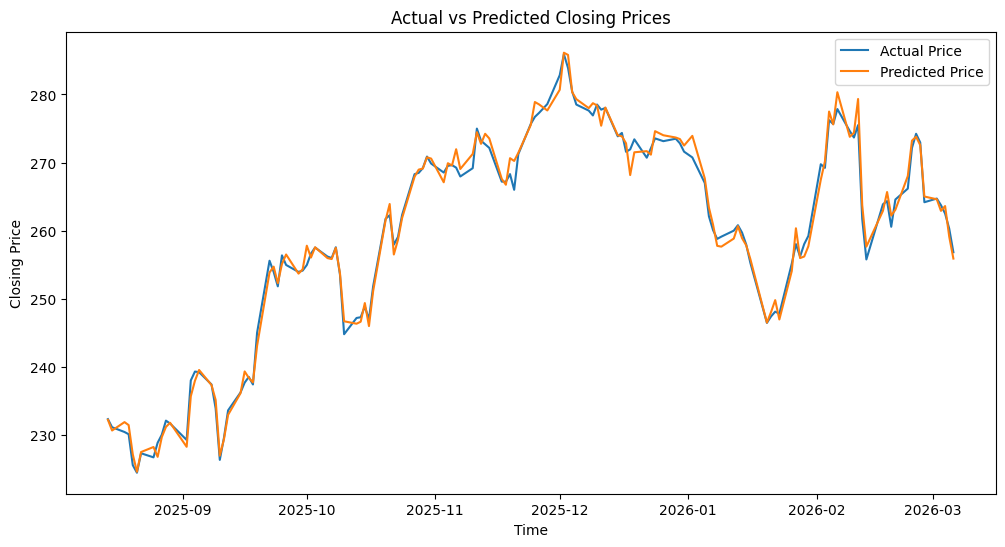

In [12]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual Price")
plt.plot(y_test.index, y_pred, label="Predicted Price")

plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.title("Actual vs Predicted Closing Prices")

plt.legend()
plt.show()